## Navigo Cardiac Reprogramming: Inhibition Analysis

This tutorial uses Navigo to model the effect of silencing cardiomyocyte regulators during fibroblast reprogramming, and infers a 3-layer gene regulatory network.

In [1]:
import warnings, torch
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

import navigo, navigo.pl
from navigo import run_perturbation_inference, set_seed
from navigo.network import collect_edges, plot_three_layer_network

warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

## Configuration

In [2]:
DATA_DIR       = Path("/scratch/users/steorra/analysis/26_yimin/data")
CHECKPOINT_DIR = Path("/scratch/users/steorra/analysis/26_yimin/checkpoints")
OUTPUT_DIR     = Path("/scratch/users/steorra/analysis/26_yimin/Navigo-release/docs/tutorials/outputs")

data_shared_dir  = DATA_DIR / 'shared'
case_output_root = OUTPUT_DIR / 'reprogramming_cardiac_inhibition'

CHECKPOINT_PATH  = CHECKPOINT_DIR / 'reprogramming' / 'cardiac_reprogramming_checkpoint.pth'
DATA_PATH        = data_shared_dir / 'mouse_heart_fibroblasts.h5ad'
TARGET_LIST_PATH = data_shared_dir / 'cardiomyocyte_inhibition_targets.csv'

INFERRED_DIR = case_output_root / '01_inference_csv'
FIGURE_DIR   = case_output_root / '02_figures'
SUMMARY_DIR  = case_output_root / '03_summaries'

for d in [INFERRED_DIR, FIGURE_DIR, SUMMARY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
set_seed(0)

## Step 1: Run perturbation inference

In [3]:
inference_summary = run_perturbation_inference(
    data_path=DATA_PATH, checkpoint_path=CHECKPOINT_PATH,
    target_list_path=TARGET_LIST_PATH, output_dir=INFERRED_DIR,
    fibro_cell_type='Fibroblasts', input_dim=7804, hidden_1=5012, hidden_2=5012,
    flow_num_steps=100, simulation_steps=10,
    knockout_scale=3.0, device=DEVICE, strict_target_presence=False,
)
print(f"Generated {len(list(INFERRED_DIR.glob('*.csv')))} inference CSV files.")

Perturbation inference:   0%|                                                                                      | 0/57 [00:00<?, ?it/s]

Perturbation inference:   2%|█▎                                                                            | 1/57 [00:01<01:21,  1.46s/it]

Perturbation inference:   4%|██▋                                                                           | 2/57 [00:02<01:05,  1.19s/it]

Perturbation inference:   5%|████                                                                          | 3/57 [00:04<01:19,  1.46s/it]

Perturbation inference:   7%|█████▍                                                                        | 4/57 [00:05<01:07,  1.28s/it]

...

Perturbation inference:  96%|██████████████████████████████████████████████████████████████████████████▎  | 55/57 [01:07<00:02,  1.19s/it]

Perturbation inference:  98%|███████████████████████████████████████████████████████████████████████████▋ | 56/57 [01:08<00:01,  1.13s/it]

Perturbation inference: 100%|█████████████████████████████████████████████████████████████████████████████| 57/57 [01:09<00:00,  1.09s/it]

Perturbation inference: 100%|█████████████████████████████████████████████████████████████████████████████| 57/57 [01:09<00:00,  1.23s/it]

Generated 56 inference CSV files.


## Step 2: Build regulatory network

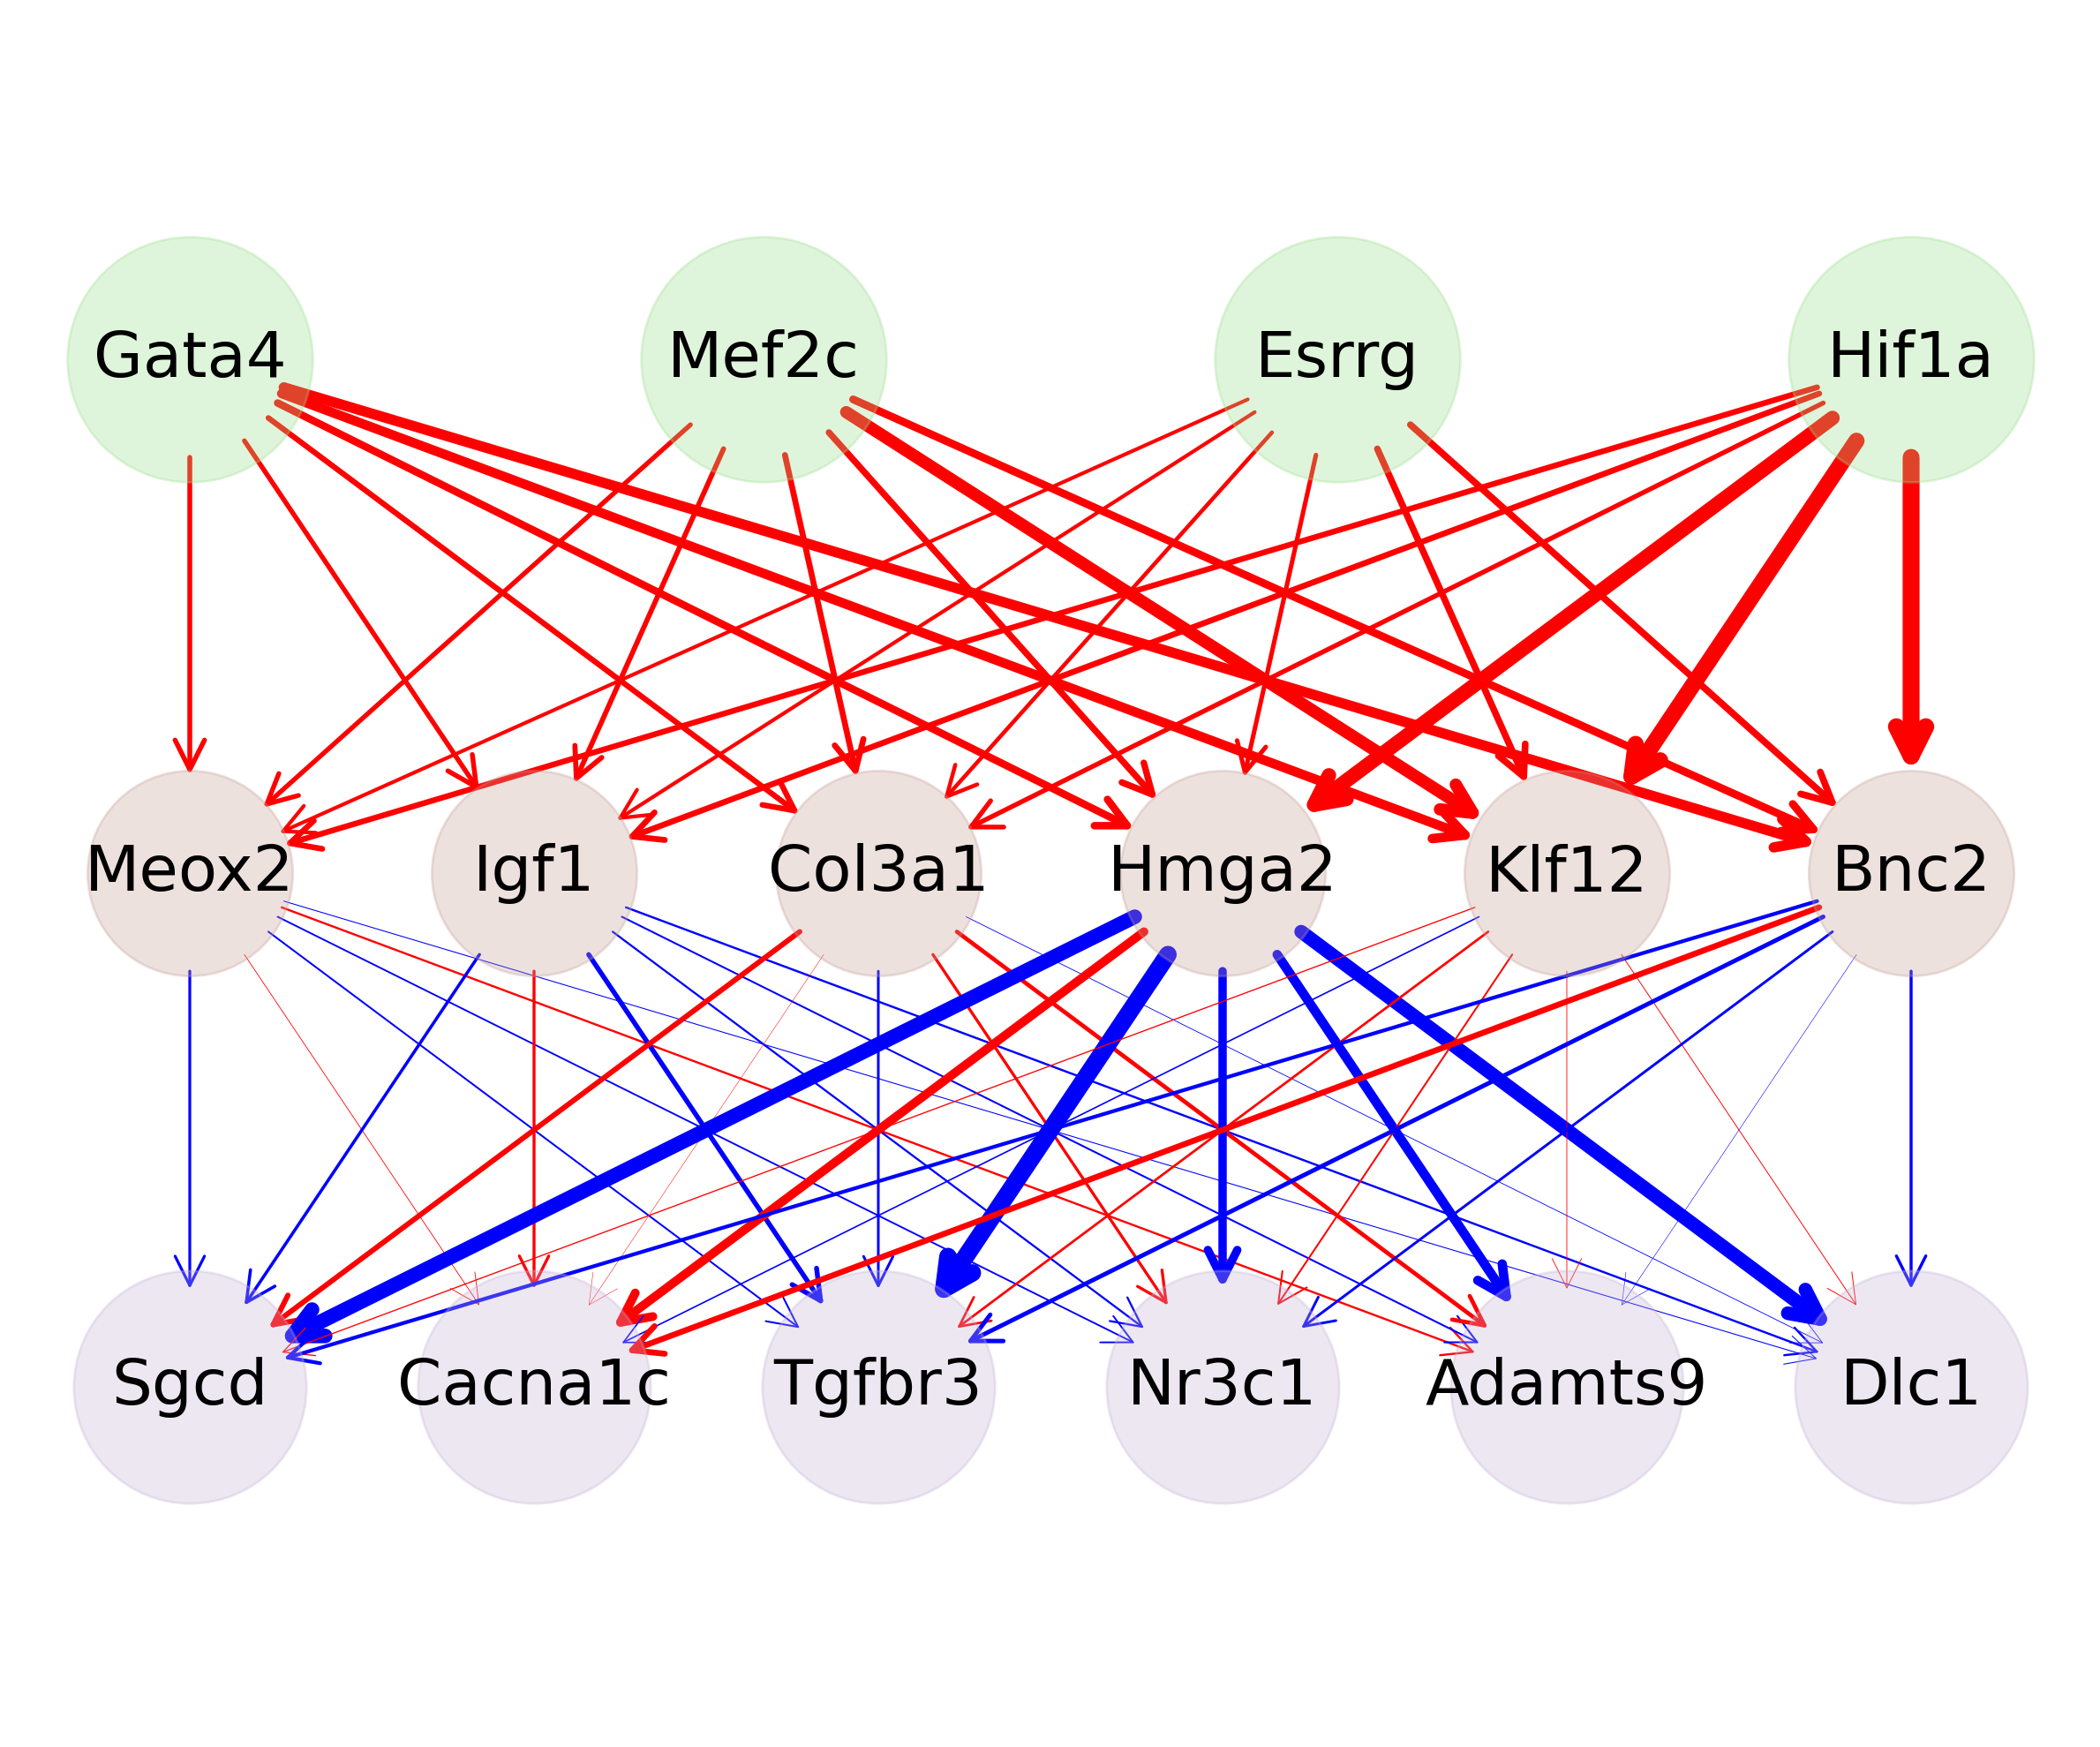

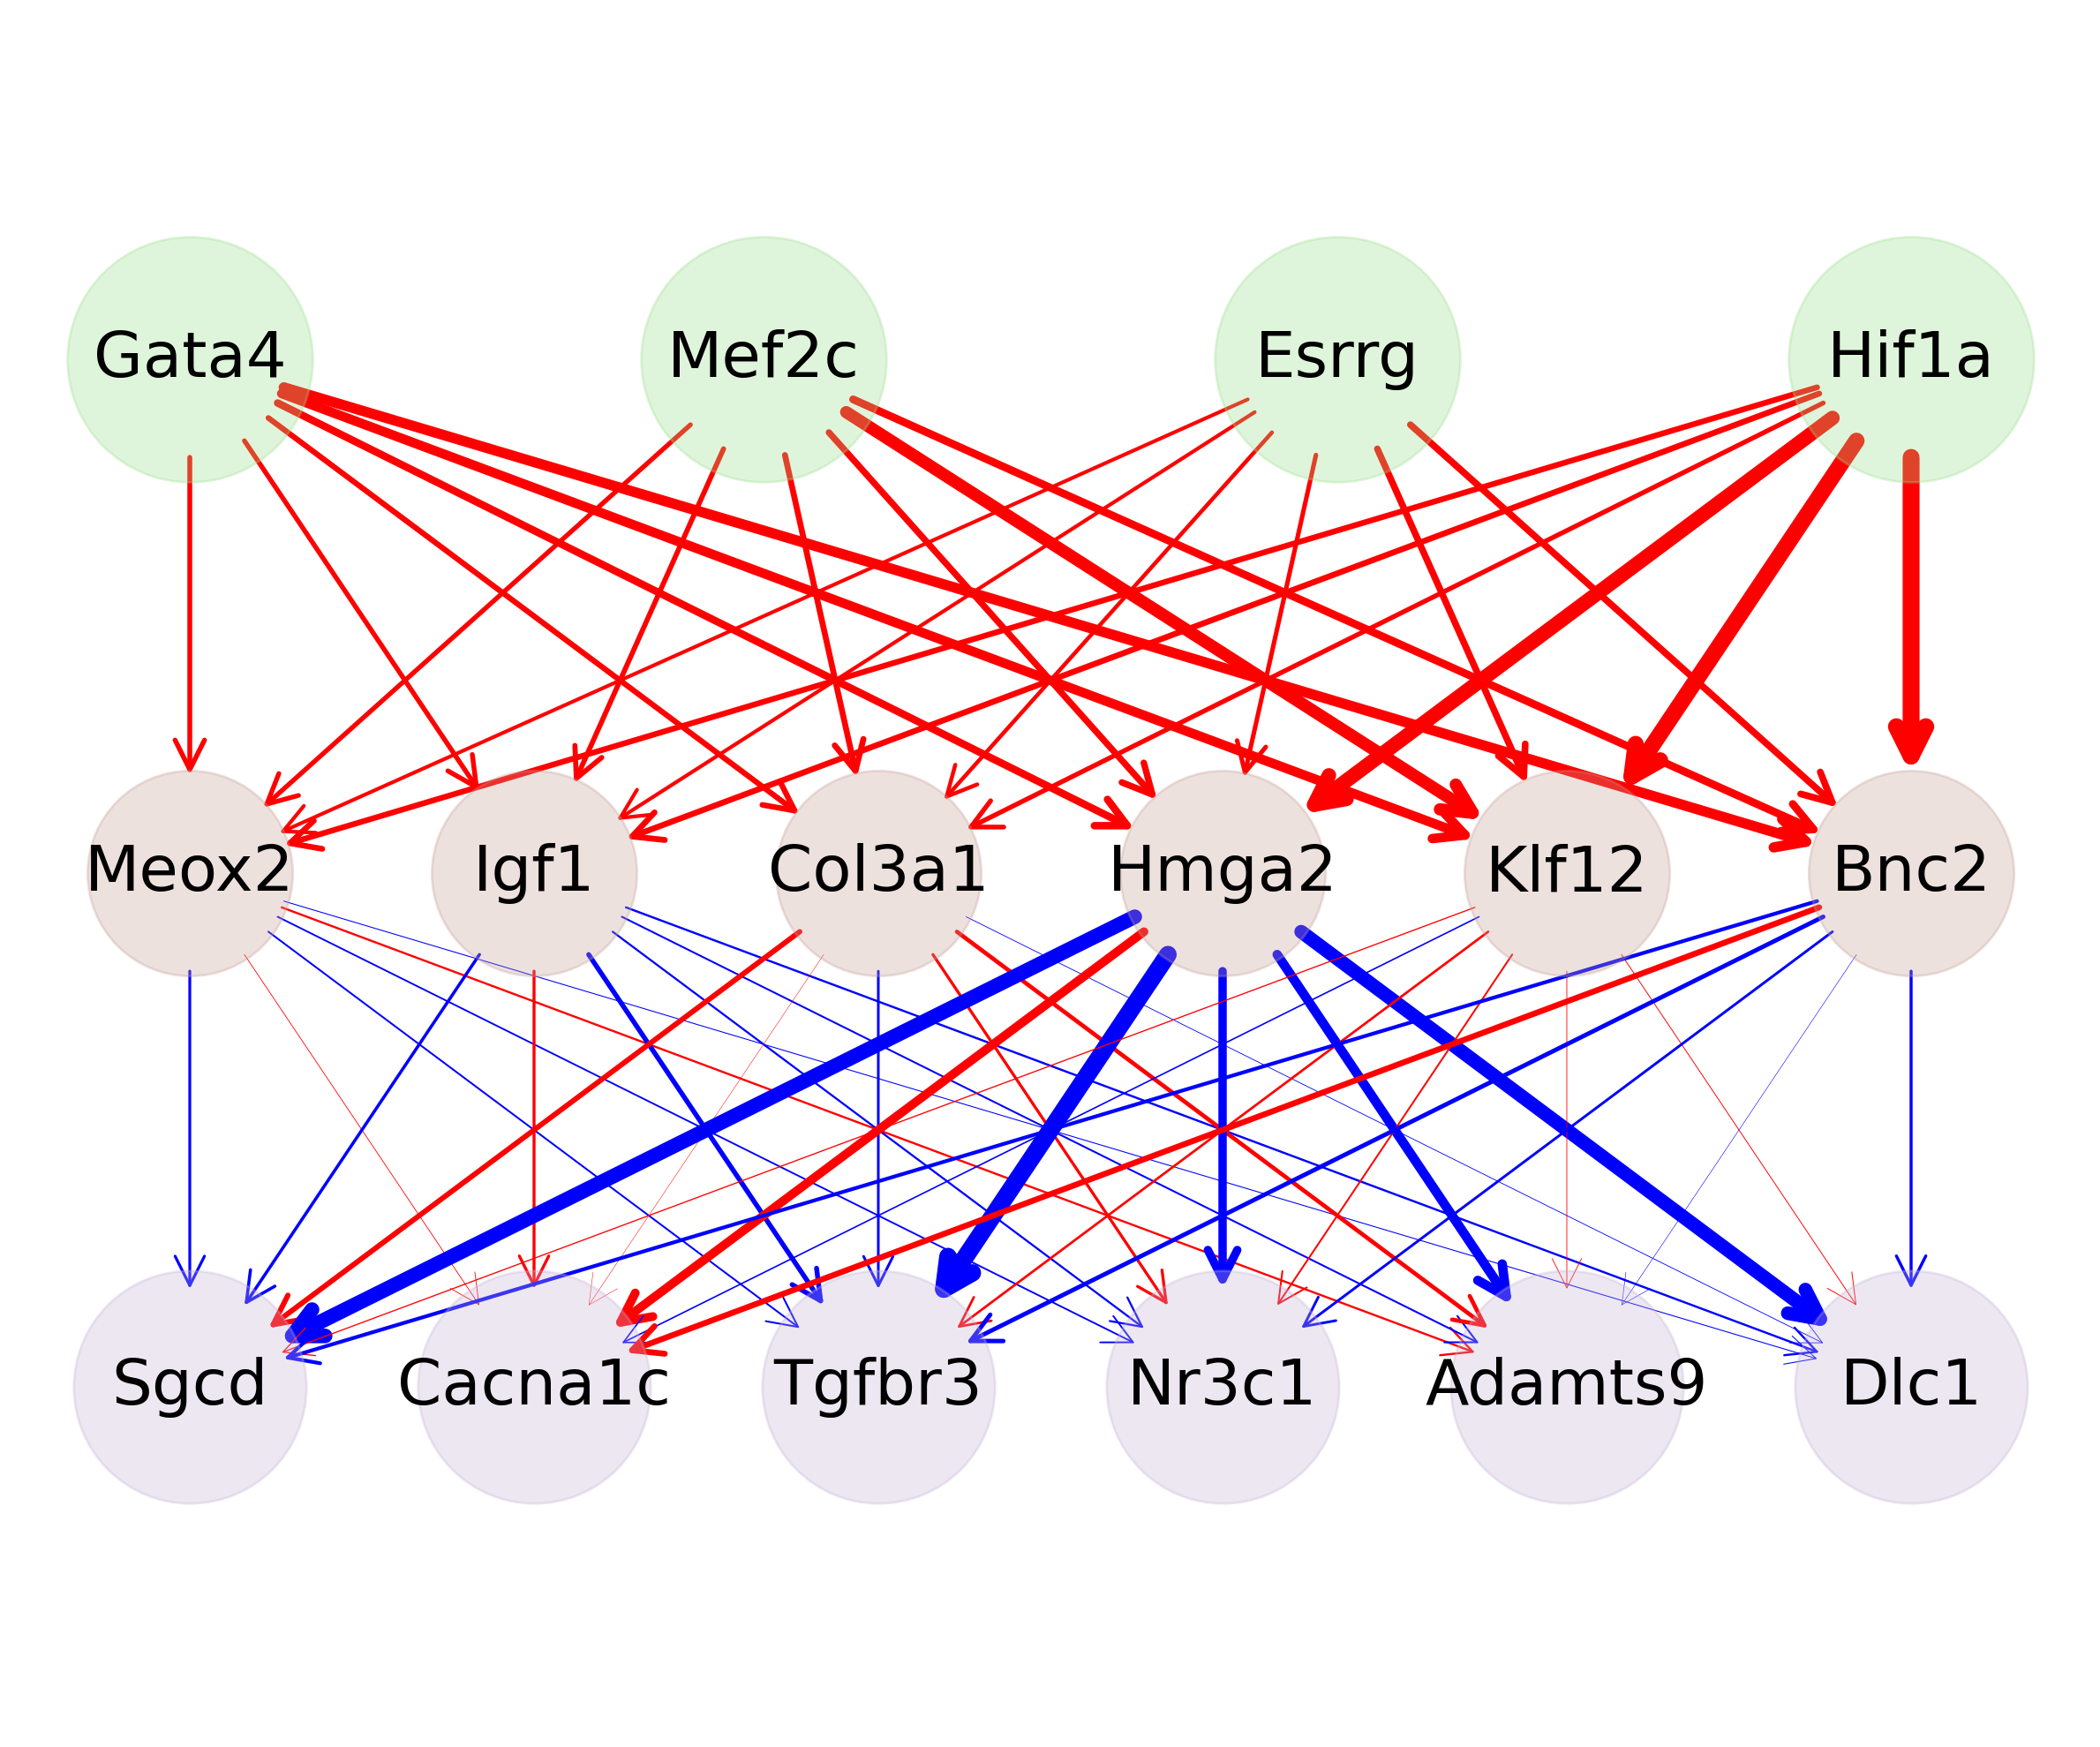

In [4]:
TOP_TFS     = ['Gata4', 'Mef2c', 'Esrrg', 'Hif1a']
FIBRO_GENES = ['Meox2', 'Igf1', 'Col3a1', 'Hmga2', 'Klf12', 'Bnc2']
CARDI_GENES = ['Sgcd', 'Cacna1c', 'Tgfbr3', 'Nr3c1', 'Adamts9', 'Dlc1']

edges, edge_colors, edge_widths, edge_df = collect_edges(INFERRED_DIR, TOP_TFS, FIBRO_GENES, CARDI_GENES)
plot_three_layer_network(TOP_TFS, FIBRO_GENES, CARDI_GENES, edges, edge_colors, edge_widths,
                        out_pdf=FIGURE_DIR / '01_three_layer_cardiac_reprogramming_network.pdf')

## Step 3: Export edge tables

In [5]:
edge_df.to_csv(SUMMARY_DIR / '01_cardiac_reprogramming_edges_all.csv', index=False)
positive_df = edge_df.sort_values('total_change', ascending=False).head(12).reset_index(drop=True)
negative_df = edge_df.sort_values('total_change', ascending=True).head(12).reset_index(drop=True)
positive_df.to_csv(SUMMARY_DIR / '01_top_positive_edges.csv', index=False)
negative_df.to_csv(SUMMARY_DIR / '01_top_negative_edges.csv', index=False)
positive_df

,source,target,layer,total_change
0,Hif1a,Bnc2,TF->Fibro,0.006888
1,Hif1a,Klf12,TF->Fibro,0.006595
2,Hif1a,Hmga2,TF->Fibro,0.005899
3,Mef2c,Klf12,TF->Fibro,0.005009
4,Gata4,Bnc2,TF->Fibro,0.004193
5,Gata4,Klf12,TF->Fibro,0.003857
6,Hmga2,Cacna1c,Fibro->Cardio,0.003567
7,Mef2c,Bnc2,TF->Fibro,0.003178
8,Gata4,Hmga2,TF->Fibro,0.003051
9,Esrrg,Bnc2,TF->Fibro,0.002762
